# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
from scipy.optimize import curve_fit

In [3]:
from ase.eos import EquationOfState, birchmurnaghan

In [4]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [5]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [6]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

<AxesSubplot:ylabel='Frequency'>

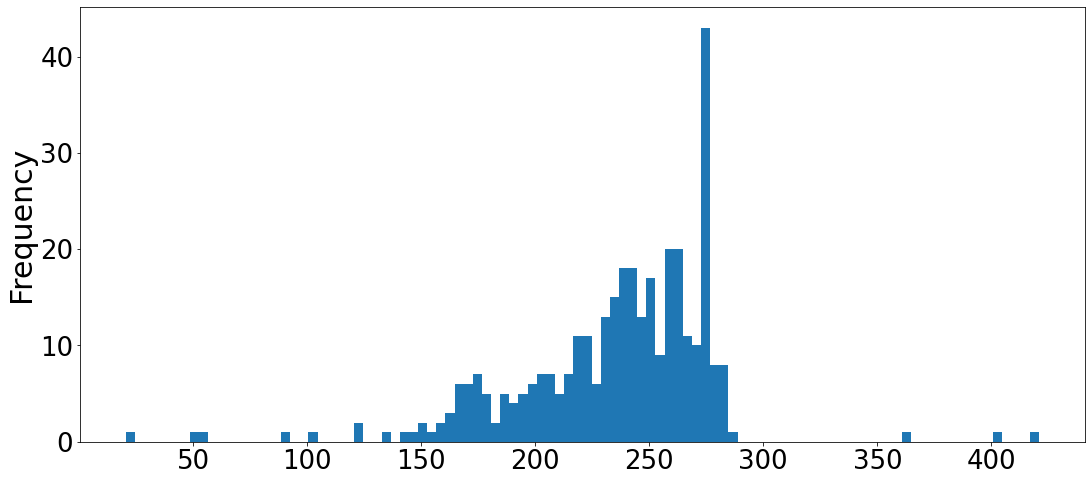

In [7]:
PBS.query('B0>0').B0.plot.hist(bins=100)

In [8]:
# PBS[PBS.index.str.contains('R')]

## Investigate ev-curves

In [9]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
force = True

In [10]:
if not os.path.exists(fittedcurvesloc) or force:
    if not os.path.exists(evcurvesloc) or force:
        print('redoing')

        EV = Evcurves(Indexes = PBS.index, atoms=dataset.split(), dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

redoing


  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

In [11]:
EVcurves[EVcurves.index.str.contains('R')]

Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R-Mo.FM                    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv53.R.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM     {'xc=PBE-PAW.E=450.dk=0.020': 

In [12]:
Mo_R = 'Mo_sv53.R.NM'

In [13]:
Fe_R = 'Fe_pv53.R.NM'

In [14]:
x = EVcurves[Fe_R]['xc=PBE-PAW.E=450.dk=0.020']['evcurve']['V']
y = EVcurves[Fe_R]['xc=PBE-PAW.E=450.dk=0.020']['evcurve']['E']

In [15]:
V0 = np.mean(x)

In [16]:
E0 = np.min(y)

In [17]:
V0

10.450377358490567

In [18]:
PBS.loc[Fe_R].B

'274.081057 GPa '

In [19]:
EVcurves[Mo_R]['xc=PBE-PAW.E=450.dk=0.020']

{'evcurve': {'V': array([13.97809906, 13.90991321, 13.84172736, 13.77354151, 13.70535566,
         13.63716981, 13.56898396, 13.50079811, 13.43261226, 13.36442642,
         13.29624057]),
  'E': array([-9.56791698, -9.57003264, -9.57165604, -9.57277509, -9.57337585,
         -9.57345113, -9.5729717 , -9.57193434, -9.57032113, -9.56811057,
         -9.56529736])},
 'ev_fit_results': {'E_murn': -10.625314,
  'V_murn': 16.315439,
  'B_murn': 238.808096,
  'Bdev_murn': 4.121263},
 'r2': 0.9999997050368252,
 'fit': array([-9.57348522,  1.58987668,  4.41437303, 13.6623093 ]),
 'IsGood': True}

In [20]:
indexofgoodsamples = []
for index, data in EVcurves.items():
    for params, evcurve in data.items():
        if  evcurve['IsGood']:
            indexofgoodsamples.append(index)
indexofgoodsamples = pd.Index(indexofgoodsamples)

In [21]:
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[EVcurves.index.difference(indexofgoodsamples)]

In [22]:
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]

In [23]:
BadBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv1.fcc.FM,bulk fcc.FM,0.000000 A,-7.912043,-2.685409 GPa,murnaghan volume_relaxed,PBE-PAW,480,0.020,0,1,-2.685409,0.000000,Fe_pv,,1,0,1
Fe_pv10Mo_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,14.791477 A,-9.413408,194.257707 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,194.257707,14.791477,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-ABBBA.FM,bulk C36-ABBBA.FM,13.975813 A,-9.446499,-157.020416 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-157.020416,13.975813,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,14.595271 A,-9.414958,420.901429 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,420.901429,14.595271,Fe_pv,Mo_sv,10,14,24
Fe_pv10Mo_sv14.C36-BABBA.FM,bulk C36-BABBA.FM,14.599262 A,-9.464137,249.350538 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,249.350538,14.599262,Fe_pv,Mo_sv,10,14,24
Fe_pv11Mo_sv2.mu-AAABA.FM,bulk mu-AAABA.FM,8.318826 A,-8.453835,-271.520165 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-271.520165,8.318826,Fe_pv,Mo_sv,11,2,13
Fe_pv11Mo_sv2.mu-AABAA.FM,bulk mu-AABAA.FM,12.022507 A,-8.459843,-6867.530562 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-6867.530562,12.022507,Fe_pv,Mo_sv,11,2,13
Fe_pv12Mo_sv12.C36-AAABB.FM,bulk C36-AAABB.FM,14.631811 A,-9.098397,173.539303 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,173.539303,14.631811,Fe_pv,Mo_sv,12,12,24
Fe_pv12Mo_sv17.chi-BBAB.FM,bulk chi-BBAB.FM,14.233801 A,-9.552726,203.021600 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,203.021600,14.233801,Fe_pv,Mo_sv,12,17,29
Fe_pv13Mo_sv16.chi-ABAB.FM,bulk chi-ABAB.FM,14.058613 A,-9.439938,-320.617353 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,-320.617353,14.058613,Fe_pv,Mo_sv,13,16,29


## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [24]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains(r'\..*[UD]+$') ]

## Obtain some info from indexes

In [25]:
Features = Featurizer(GoodBS)

In [26]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,224.285410,14.954763,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,237.907324,14.130625,Fe_pv,Mo_sv,10,20,30,0.333333,0.666667
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,204.470374,16.270923,Fe_pv,Mo_sv,4,20,24,0.166667,0.833333
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,216.183583,15.751001,Fe_pv,Mo_sv,5,24,29,0.172414,0.827586
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,255.953497,14.436090,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,240.020984,15.125643,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,247.238692,14.698886,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,223.435464,14.806728,Fe_pv,Mo_sv,1,3,4,0.250000,0.750000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,207.683558,15.095159,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333


In [27]:
GoodBS.shape

(281, 19)

## translate structures to their bases

# TODo this sould be in tools, as a phase cleaner

In [28]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [29]:
Target_Class

Fe_pv8Mo_sv22.sigma-BBABB.FM       sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM      sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM           C36
Fe_pv5Mo_sv24.chi-AABB.FM            chi
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM        R
                                   ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM             mu
Fe_pv8Mo_sv22.sigma-BBABB.NM       sigma
Fe_pv1Mo_sv3.L12-AB3.FM              fcc
Fe_pv8Mo_sv22.sigma-BBBBA.FM       sigma
Fe_pv10Mo_sv20.sigma-ABBAB.NM      sigma
Length: 281, dtype: object

In [30]:
dataset

'Fe-Mo'

In [31]:
DescriptorsLoc = os.path.join(dataset,'Descriptors')
if not os.path.exists(DescriptorsLoc):
    os.makedirs(DescriptorsLoc)

In [32]:
Target_Class.to_pickle(os.path.join(DescriptorsLoc, 'ClassLabels.pkl'))

In [33]:
GoodBS['Phase'] = Target_Class

In [34]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000
mean,-9.335929,1.846975,234.154084,13.555226,13.266904,10.241993,23.508897,0.502848,0.497152
std,0.747150,0.360654,34.763955,1.648317,11.234669,9.575181,13.965036,0.292321,0.292321
min,-10.932826,1.000000,91.497861,10.193118,1.000000,0.000000,1.000000,0.000000,0.000000
25%,-9.951022,2.000000,217.305518,12.260775,5.000000,3.000000,13.000000,0.266667,0.266667
50%,-9.319758,2.000000,241.100481,13.304001,10.000000,8.000000,24.000000,0.500000,0.500000
75%,-8.791443,2.000000,260.447219,14.876555,18.000000,16.000000,30.000000,0.733333,0.733333
max,-7.780040,2.000000,287.396036,16.550514,56.000000,52.000000,56.000000,1.000000,1.000000


# some E-V curves, good and bad

In [35]:
sample_bad_index = BadBS.sample(n=5).index.append(pd.Index(['Mo_sv53.R.NM'])).unique()

In [36]:
sample_bad = EVcurves[sample_bad_index] #[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [37]:
sample_bad

Fe_pv12Mo_sv17.chi-BBAB.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1.fcc.FM                  {'xc=PBE-PAW.E=480.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv8.C36-ABBAA.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv14Mo_sv10.C36-BAABA.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv18Mo_sv6.C36-AAABA.FM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv53.R.NM                   {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [38]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [39]:
sample_bad_r2 = R2[sample_bad.index]

In [40]:
sample_bad_fit = Fits[sample_bad.index]

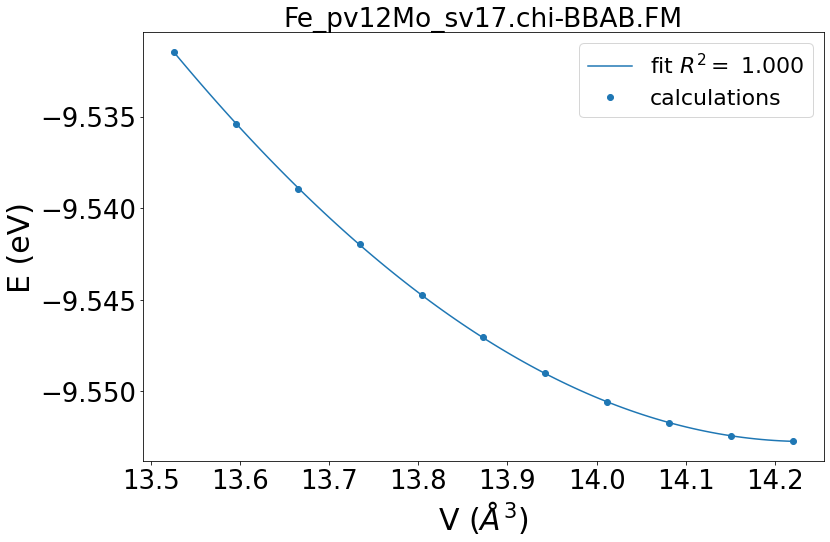

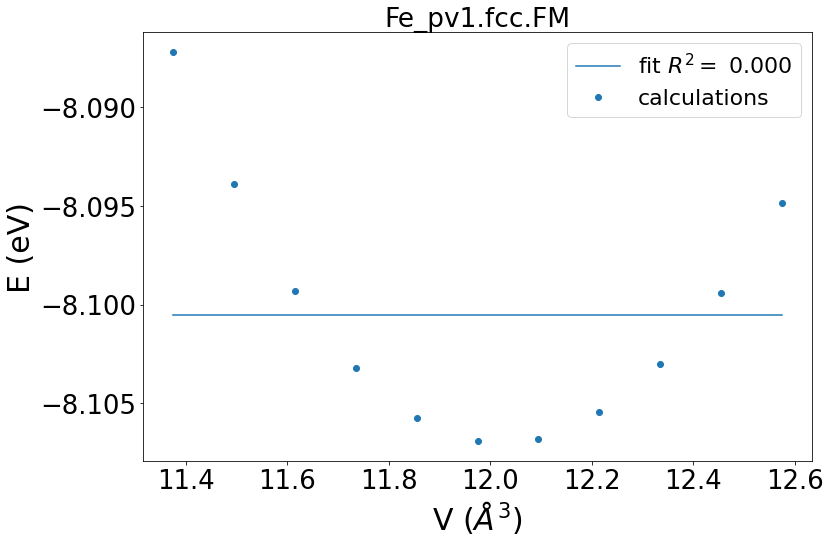

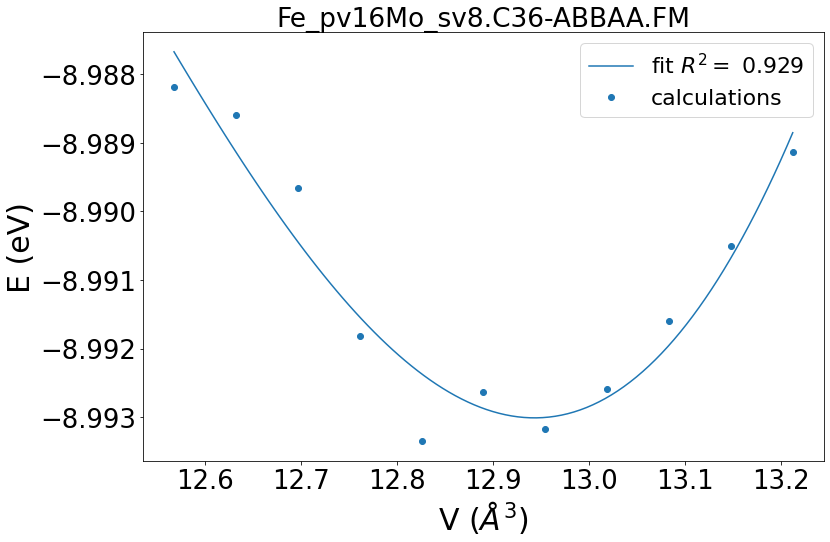

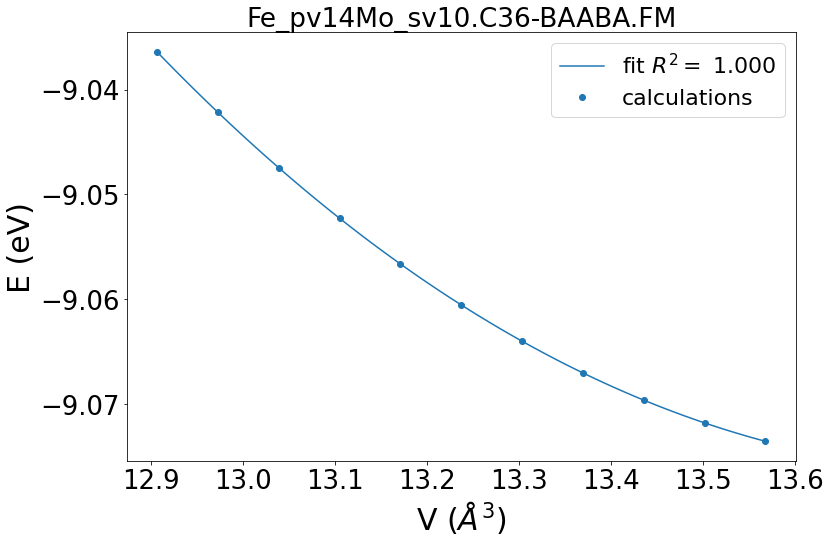

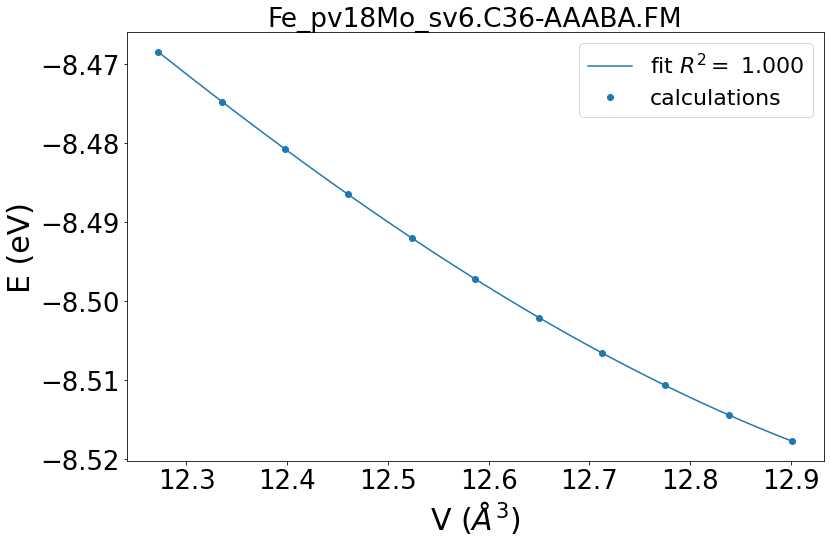

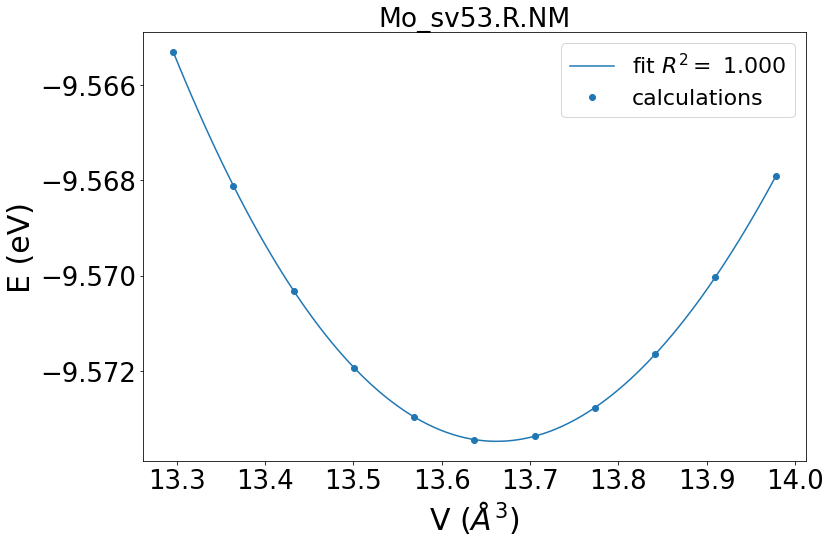

In [41]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

In [42]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [43]:
sample_good

Mo_sv8.A15.NM                   {'xc=PBE-PAW.E=400.dk=0.016': {'evcurve': {'V'...
Fe_pv2Mo_sv2.B32-AB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv22Mo_sv8.sigma-AAAAB.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv4.fcc-cubic.NM             {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv2.hcp.FM                   {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
dtype: object

In [44]:
Goodness[sample_good.index]

Mo_sv8.A15.NM                   {'xc=PBE-PAW.E=400.dk=0.016': True}
Fe_pv2Mo_sv2.B32-AB.NM          {'xc=PBE-PAW.E=450.dk=0.020': True}
Fe_pv22Mo_sv8.sigma-AAAAB.FM    {'xc=PBE-PAW.E=450.dk=0.020': True}
Mo_sv4.fcc-cubic.NM             {'xc=PBE-PAW.E=450.dk=0.020': True}
Mo_sv2.hcp.FM                   {'xc=PBE-PAW.E=400.dk=0.020': True}
dtype: object

In [45]:
sample_good_r2 = R2[sample_good.index]

In [46]:
sample_good_fit = Fits[sample_good.index]

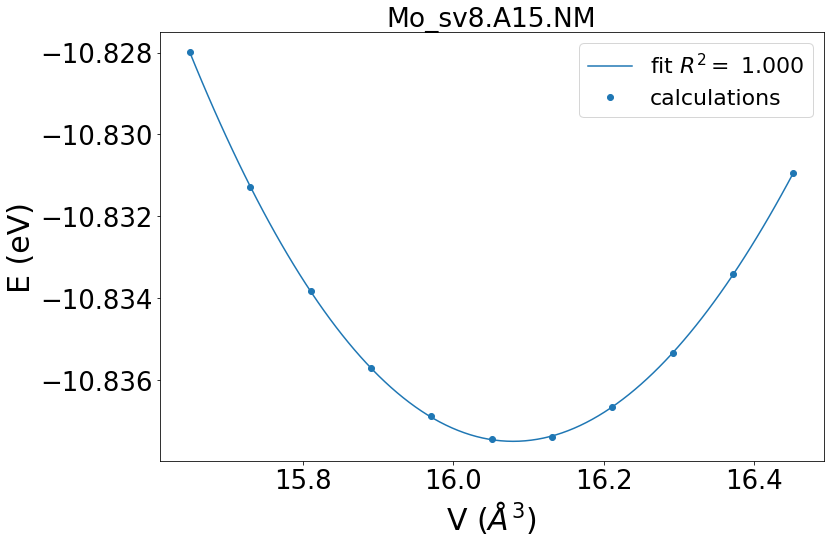

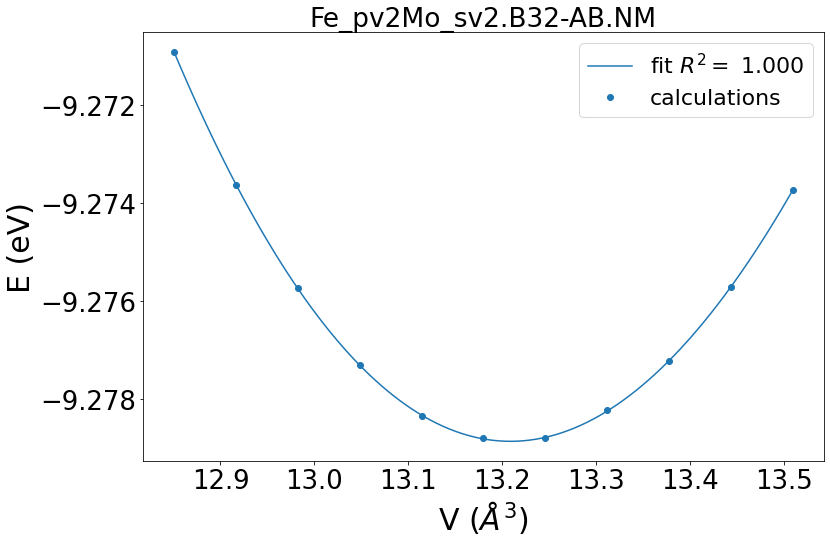

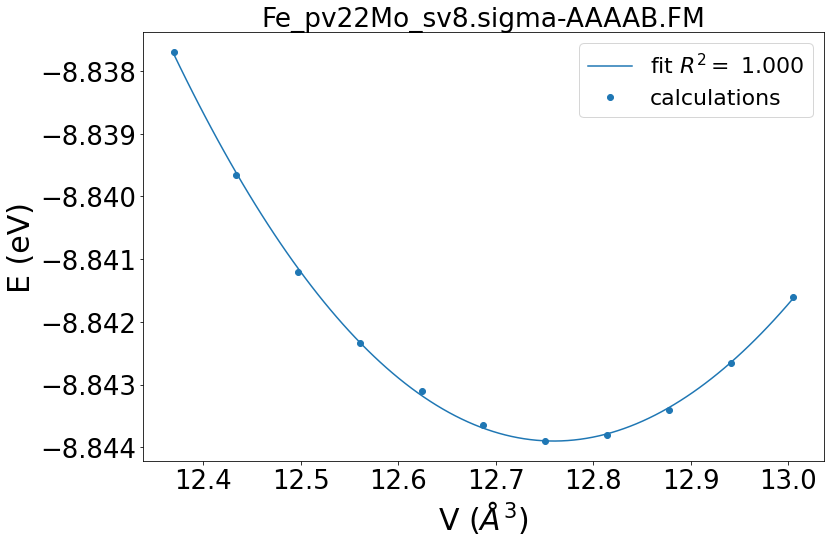

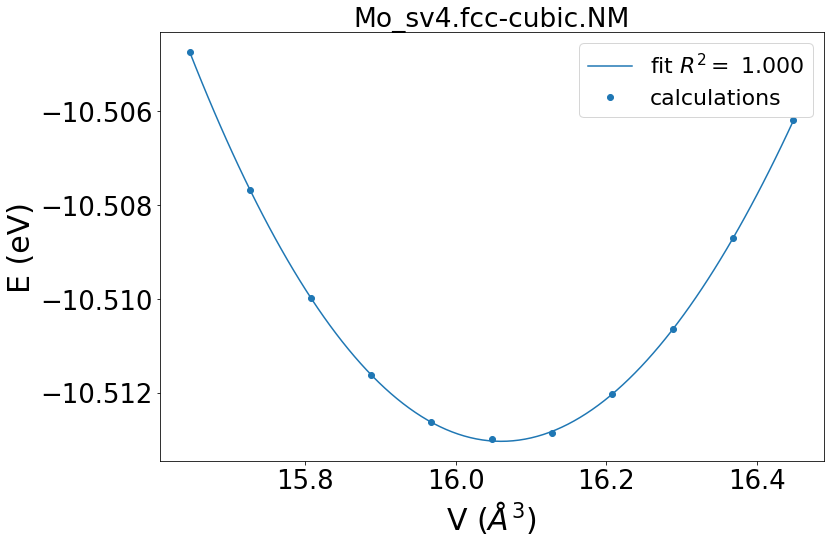

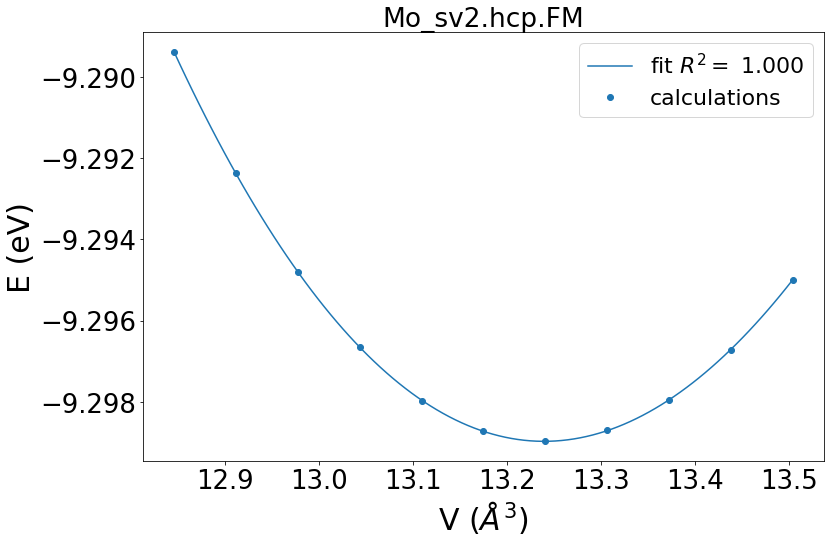

In [47]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

still high and low B0s

<AxesSubplot:>

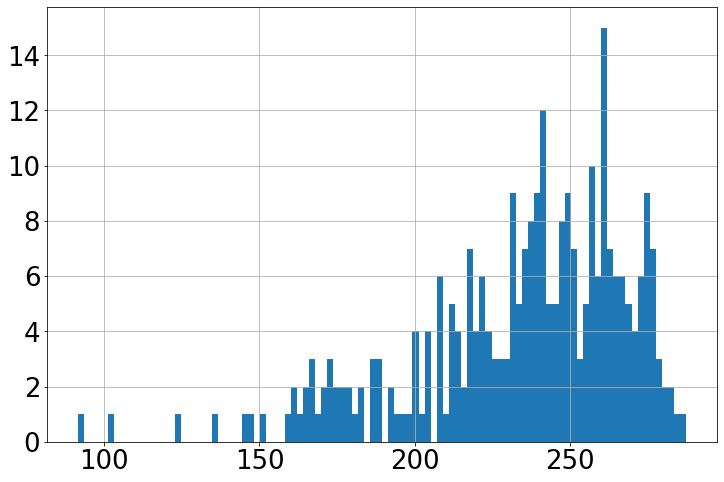

In [48]:
GoodBS.B0.hist(bins=100)

In [49]:
GoodBS.query('nelem == 1').B0.idxmin()

'Fe_pv8.A15.FM'

In [50]:
GoodBS.query('nelem == 1').B0.idxmax()

'Fe_pv2.hcp.NM'

In [51]:
sample_max_B0 = GoodBS.query('nelem == 1').B0.idxmax()

In [52]:
sample_min_B0 = GoodBS.query('nelem == 1').B0.idxmin()

In [53]:
sample_min_B0

'Fe_pv8.A15.FM'

In [54]:
GoodBS.B0[sample_min_B0]

91.497861

In [55]:
sample_max_B0

'Fe_pv2.hcp.NM'

In [56]:
GoodBS.B0[sample_max_B0]

287.396036

In [57]:
selection = ((GoodBS.B0>=GoodBS.B0[sample_min_B0]) & (GoodBS.B0<=GoodBS.B0[sample_max_B0]))

In [58]:
selection.sum()

281

In [59]:
selection_stricter = ((GoodBS.B0>1.1*GoodBS.B0[sample_min_B0]) & (GoodBS.B0<0.90*GoodBS.B0[sample_max_B0]) &
                     (list(R2[sample_max_B0].values())[0] > 0.998))

In [60]:
selection_stricter

Fe_pv8Mo_sv22.sigma-BBABB.FM        True
Fe_pv10Mo_sv20.sigma-ABBAB.FM       True
Fe_pv4Mo_sv20.C36-ABBBB.FM          True
Fe_pv5Mo_sv24.chi-AABB.FM           True
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM     True
                                   ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM           True
Fe_pv8Mo_sv22.sigma-BBABB.NM        True
Fe_pv1Mo_sv3.L12-AB3.FM             True
Fe_pv8Mo_sv22.sigma-BBBBA.FM        True
Fe_pv10Mo_sv20.sigma-ABBAB.NM      False
Name: B0, Length: 281, dtype: bool

In [61]:
samples_wrong_b0 = GoodBS[~selection].index

In [62]:
len(samples_wrong_b0)

0

<AxesSubplot:ylabel='Frequency'>

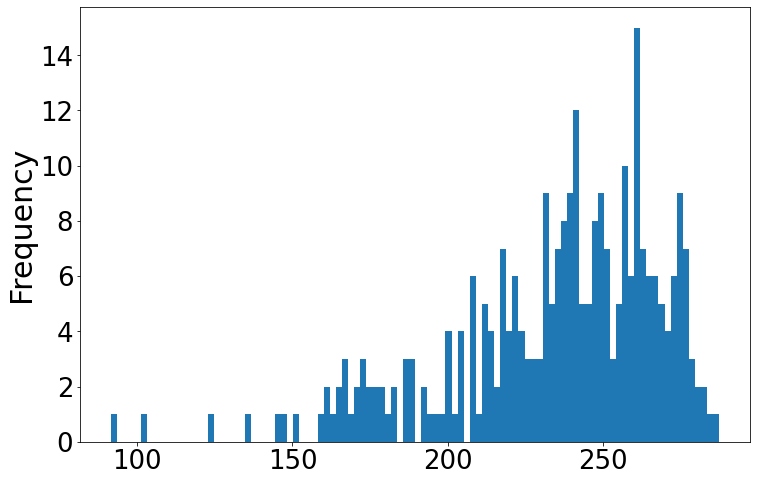

In [63]:
GoodBS.B0.plot.hist(bins=100)

In [64]:
samples_wrong_b0

Index([], dtype='object')

In [65]:
curve_wrong_b0 = EVcurves[samples_wrong_b0]

In [66]:
r2_wrong_b0 = R2[samples_wrong_b0]

In [67]:
fits_wrong_b0 = Fits[samples_wrong_b0]

In [68]:
curve_wrong_b0

Series([], dtype: object)

In [69]:
figurecollection, axcollection  = plot_curves(curve_wrong_b0, fits_wrong_b0, r2_wrong_b0)
for ax, index  in zip(axcollection, samples_wrong_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

In [70]:
GoodBS.drop(index=samples_wrong_b0, inplace=True)

In [71]:
samples_low_b0 = GoodBS.query('B0 < 150').index

In [72]:
curve_low_b0 = EVcurves[samples_low_b0]

In [73]:
r2_low_b0 = R2[samples_low_b0]

In [74]:
fits_low_b0 = Fits[samples_low_b0]

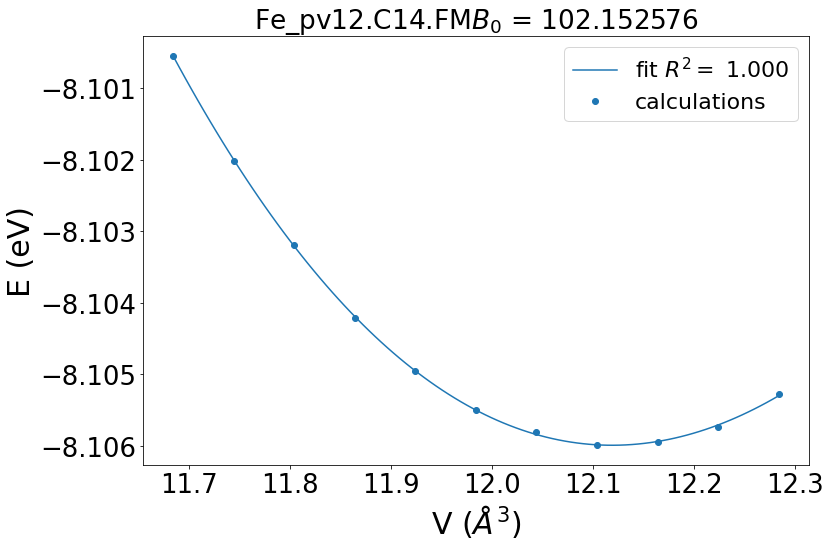

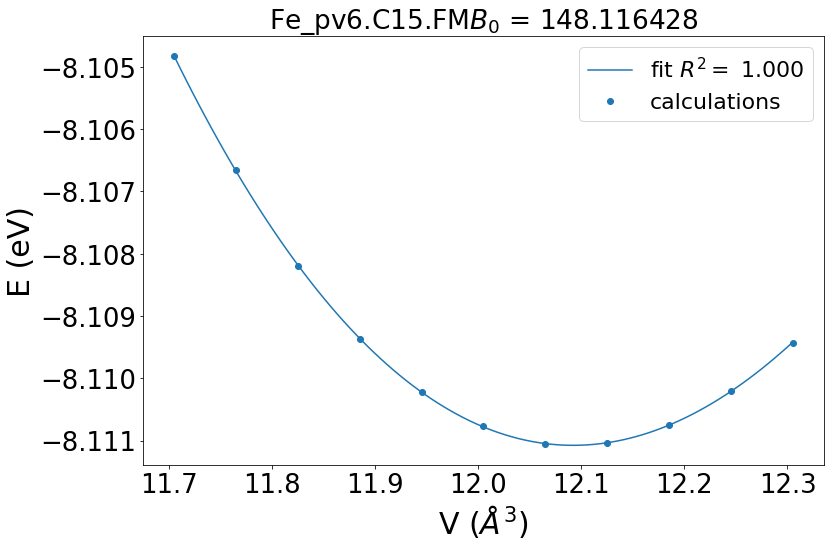

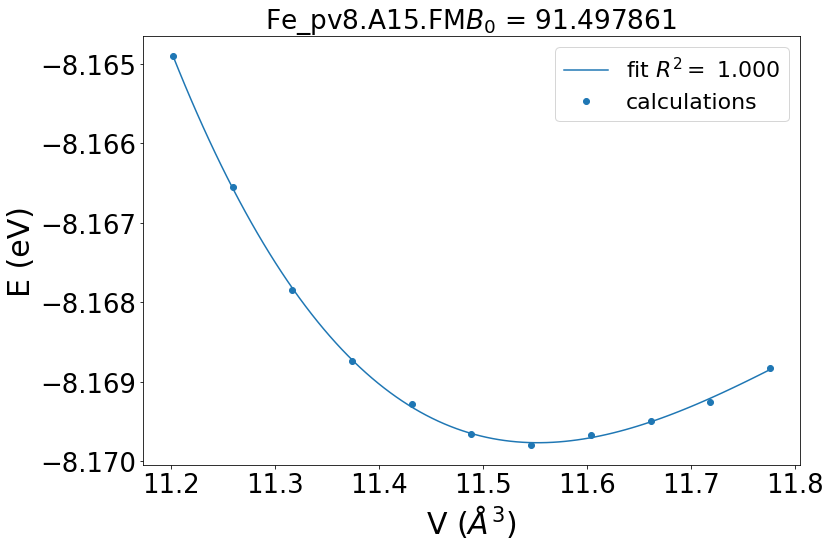

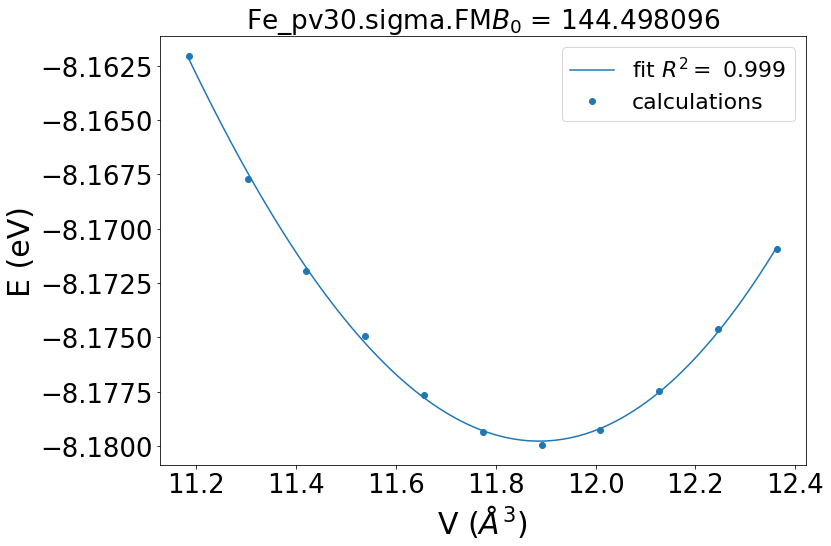

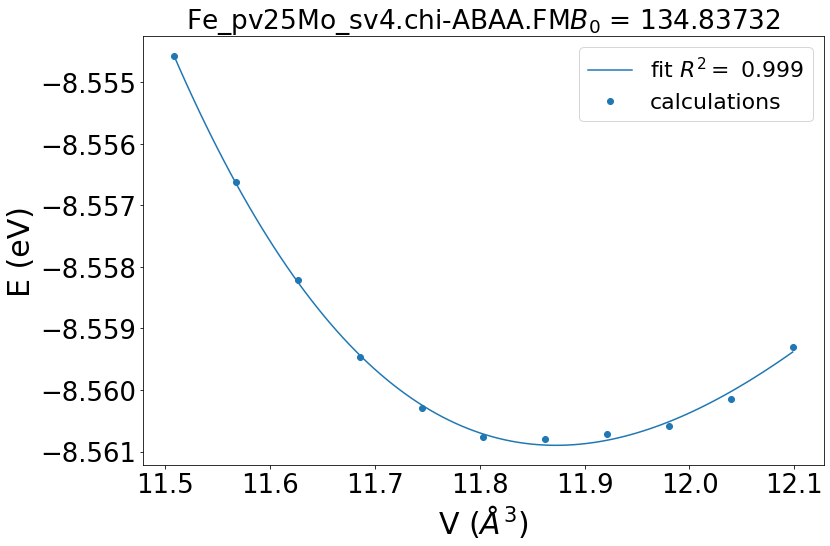

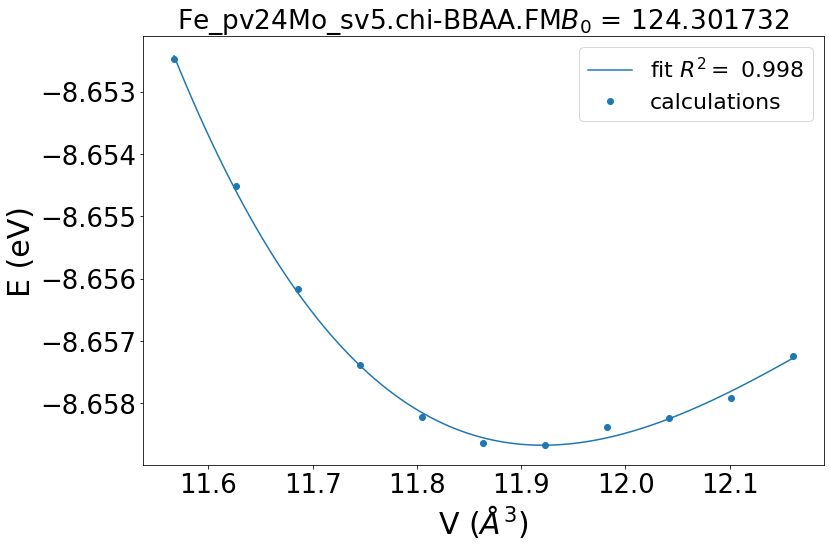

In [75]:
figurecollection, axcollection  = plot_curves(curve_low_b0, fits_low_b0, r2_low_b0)
for ax, index  in zip(axcollection, samples_low_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

# Save for later use 

In [76]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

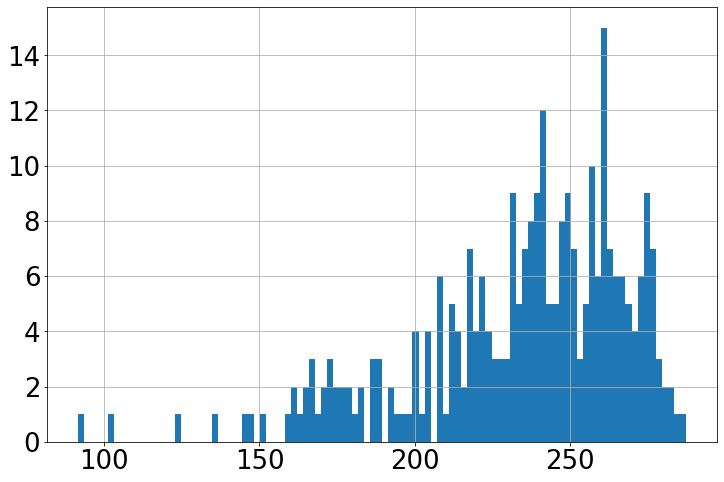

In [77]:
GoodBS.B0.hist(bins=100)

In [78]:
PBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,224.285410,14.954763,Fe_pv,Mo_sv,8,22,30
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,237.907324,14.130625,Fe_pv,Mo_sv,10,20,30
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,204.470374,16.270923,Fe_pv,Mo_sv,4,20,24
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,402.123952,15.378254,Fe_pv,Mo_sv,3,10,13
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,216.183583,15.751001,Fe_pv,Mo_sv,5,24,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,240.020984,15.125643,Fe_pv,Mo_sv,3,10,13
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,247.238692,14.698886,Fe_pv,Mo_sv,8,22,30
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,223.435464,14.806728,Fe_pv,Mo_sv,1,3,4
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,207.683558,15.095159,Fe_pv,Mo_sv,8,22,30
